# Train conn_adj on a mixed dataset (self-contained, Run All)

Обучает RL edit-агент варианта **`conn_adj`** (objective = **connectivity-only** +
adjustment-degree shaping). Mixed-датасет **генерируется прямо здесь** (heuristic /
LC-α / RPC) и сохраняется на диск — отдельный шаг не нужен, просто **Run All**.

**Conditioning (по умолчанию ВКЛ).** Агент **учится под разные** `target`/`W`:
per-graph сэмплируются `target~U[0.1,0.4]` и `W~log-U[2,50]` и подаются в global-
фичи модели (`n_adjustment_cond_feats=2`), чтобы политика адаптировала «бюджет
переписывания» под запрошенный верхний порог adjustment. Это **gated**:
construction-модель (12 global-фич) не трогается — расширяются только scorer'ы
edit-модели. На оценке модель прогоняется в фикс. точке `EVAL_ADJ_TARGET`/`EVAL_ADJ_WEIGHT`.
Выключается через `CONDITION_ON_ADJ=False` (тогда фикс. `ADJ_TARGET`/`ADJ_WEIGHT`).

> **Итог 1-го прогона (W=[0.5,8]):** conditioning не выучился (adj≈0.24 при любых
> target/W). При `cap` главный рычаг — **W**, и слабый диапазон не «кусал»
> достаточно. W усилен до **[2,50]**. Управляемость проверяется двумя свипами в
> конце: по `target` и (главный для cap) по `W`.

**Меньшие настройки** (быстрый прогон): 50 узлов, 12 маршрутов, длина 8–15.

**Изоляция от обычного train_improvement.** Имена отдельные:
- веса → `improvement_conn_adj_mixed.pt` (train_improvement = `improvement_lc_improvement_trim.pt`);
- история → `conn_adj_mixed_training_history.csv`;
- сравнение → `conn_adj_mixed_vs_train_improvement.csv`.

Свежая модель строится из cfg (random init) → веса train_improvement не читаются
и не перезаписываются (читаются только в финальном сравнении).

**В конце** — сравнение двух моделей на сгенерированном val: `conn_adj_mixed`
(in-distribution, conditioned) против `train_improvement` (старая модель,
zero-shot, не-conditioned), под единым полным objective (ATT/RTT/MC + adjustment).

In [1]:
import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # выбери GPU при необходимости
import sys
import pickle
import shutil
import random as _random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from hydra import compose, initialize_config_dir
from IPython.display import display

from eval_lib.context import (ROOT_DIR, CFG_DIR, DATASETS_DIR,
                              MODEL_OUTPUTS_DIR, EDIT_MODEL_WEIGHTS_DIR)
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from connectpt.routes_generator import utils as lrnu
from connectpt.routes_generator.improvement_learning import (
    load_raw_graphs_and_lc_routes, make_improvement_batch,
    rollout_lc_improvement, train_lc_improvement_cfg)
from connectpt.routes_generator.bee_colony import get_adjustment_degrees
from connectpt.routes_generator.torch_utils import (
    get_batch_tensor_from_routes, dump_routes)
from connectpt.routes_generator.transit_time_estimator import RouteGenBatchState
from connectpt.routes_generator.nx_heuristic import build_nx_heuristic_routes
from connectpt.routes_generator.citygraph_dataset import (
    STOP_KEY, DynamicCityGraphDataset)
from torch_geometric.data import Batch

from eval_lib.results_io import save_table
from eval_lib import plots as _plots
from eval_lib import build_lc_cfg, build_rpc_routes, run_lc, as_route_tensor

pd.set_option("display.max_columns", None)
print(f"Config dir: {CFG_DIR}")
print(f"Weights dir: {EDIT_MODEL_WEIGHTS_DIR}")

Config dir: D:\PythonProjects\connectpt\connectpt\routes_generator\cfg
Weights dir: D:\PythonProjects\connectpt\artifacts\model_weights\improvement


## Конфигурация

In [2]:
# --- Mixed-датасет: генерируется на диск, потом читается оттуда ---
N_PER_TYPE          = 300      # графов на тип (heuristic/lc/rpc) -> всего N_PER_TYPE*3
RAW_N_NODES         = 50       # узлов в графе ("50 точек")
RAW_GRAPH_DATA_TYPE = "mixed"  # топология street-графа (torch-cluster-фикс уже в окружении)
RAW_GRAPH_SEED      = 0
DATASET_SEED        = 0
LC_N_SAMPLES        = 1        # сэмплов LC-конструктора (берётся лучший по cost)
RPC_N_SAMPLES       = 1
# LC -- один тип; его графы делятся ~33/33/33 между alpha 0 / 0.5 / 1.
LC_WEIGHT_COMBOS = [(0.0, "route-only"), (0.5, "balanced"), (1.0, "demand-only")]

# Куда сохраняется / откуда читается датасет (на диске).
# Смена N_PER_TYPE / контракта -> датасет будет ПОЛНОСТЬЮ перегенерирован
# (см. guard по количеству графов в ячейке генерации; инкрементально дописать
# нельзя, т.к. раскладка индекс<->тип зависит от N_PER_TYPE).
DATASET_DIRNAME = "mixed_conn_adj_n50_r12_len8_15"
NEW_DATASET_DIR = DATASETS_DIR / DATASET_DIRNAME
SUBSET_PKL      = NEW_DATASET_DIR / "raw_graphs_subset.pkl"
FORCE_REGEN     = False        # True -> перегенерировать принудительно

# --- conn_adj вариант: connectivity-only + adjustment shaping ---
DISABLED_COST_COMPONENTS = ["demand", "route"]   # -> остаётся только connectivity
ADJ_OBJECTIVE = "cap"    # W*max(0, adj-target) -- линейный односторонний big-M penalty
ADJ_MODE   = "paper"
ADJ_GAP    = 0.1

# --- Conditioning: агент УЧИТСЯ под разные target/W (как cost-веса) ---
# CONDITION_ON_ADJ=True -> модель строится с доп. global-фичами
# [target, log1p(W)/log1p(8)] (n_adjustment_cond_feats=2). Во время обучения
# per-graph сэмплируются target~U[MIN,MAX] и W~log-U[MIN,MAX] и подаются агенту,
# чтобы он адаптировал «бюджет переписывания» под запрошенный порог. Это
# «gated»: construction-модель (12 global) НЕ трогается, только edit-модель.
#
# ИТОГ 1-го прогона (W=[0.5,8]): conditioning НЕ выучился -- adj≈0.24 при любых
# target/W (target-sweep плоский; W-sweep почти плоский и в обратную сторону).
# Причина магнитудная: при cap градиент штрафа = W (при adj>target), и в
# диапазоне [0.5,8] штраф W·(adj-target) НЕ превышал connectivity-выигрыш от
# переписывания, поэтому у политики не было стимула использовать conditioning.
# Усиливаем W до [2,50]: при сильном W cap реально биндит -> агент вынужден
# жаться к target -> заработают оба рычага (W и target-как-граница).
CONDITION_ON_ADJ = True
# Кондишенить ТОЛЬКО target (W фиксирован, НЕ в фичах). True -> и W в фичах.
ADJ_CONDITION_WEIGHT = False
# Подавать ли ТЕКУЩИЙ adj (vs seed) как фичу -> closed-loop: агент видит,
# сколько уже изменил, и может остановиться у target.
ADJ_CONDITION_CURRENT = True
# Сколько conditioning-фич у модели: 1 (только target) / 2 (target+W) / 0.
N_ADJ_COND_FEATS = ((1 + int(ADJ_CONDITION_WEIGHT) + int(ADJ_CONDITION_CURRENT))
                    if CONDITION_ON_ADJ else 0)  # target[+W][+current_adj]
USE_CURRENT_ADJ_EVAL = CONDITION_ON_ADJ and ADJ_CONDITION_CURRENT
ADJ_TARGET_MIN = 0.1
ADJ_TARGET_MAX = 0.4
ADJ_WEIGHT_MIN = 1.0     # лог-равномерно
ADJ_WEIGHT_MAX = 15.0    # умеренно (cap_sq сам режет магнитуду/дисперсию)
# Точка, в которой conditioned-модель оценивается/визуализируется (фикс. target/W).
# target=верхний порог при оценке; W=geo-mean диапазона (~10).
EVAL_ADJ_TARGET = 0.15
EVAL_ADJ_WEIGHT = (((ADJ_WEIGHT_MIN * ADJ_WEIGHT_MAX) ** 0.5)
                   if ADJ_CONDITION_WEIGHT else None)  # W в фичах только если кондишенится
# W -- ФИКСИРОВАННЫЙ penalty-вес (big-M). Когда W не кондишенится
# (ADJ_CONDITION_WEIGHT=False) именно он применяется как вес штрафа и в фичи НЕ идёт.
ADJ_WEIGHT = 10.0   # big-M: > предельного выигрыша connectivity (~3.7/ед.adj)
ADJ_TARGET = EVAL_ADJ_TARGET   # тот же порог для отчёта adj>target в сравнении

# --- Контракт маршрутов (меньше) ---
TARGET_N_ROUTES = 12
MIN_ROUTE_LEN   = 8
MAX_ROUTE_LEN   = 15
MAX_ROUTE_EDIT_STEPS = MAX_ROUTE_LEN
MAX_TRIM_ACTIONS_PER_ROUTE = 1
FORCE_NONHALT_FIRST_STEP = False

# --- Обучение ---
N_ITERATIONS  = 50
BATCH_SIZE    = 16
TRAIN_FRACTION = 0.9
SPLIT_SEED    = 0

# --- Имена (ОТДЕЛЬНЫЕ от train_improvement!) ---
CFG_RUN_NAME      = "conn_adj_mixed"               # -> improvement_conn_adj_mixed
EXPERIMENT_NAME   = "conn_adj_mixed"
BASELINE_RUN_NAME = "improvement_lc_improvement_trim"  # обычный train_improvement (для сравнения)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Gen:       {N_PER_TYPE}/type x3 = {N_PER_TYPE*3} graphs, "
      f"{RAW_N_NODES} nodes, type={RAW_GRAPH_DATA_TYPE}")
print(f"Dataset:   {NEW_DATASET_DIR}  (FORCE_REGEN={FORCE_REGEN})")
print(f"Objective: connectivity-only (disabled={DISABLED_COST_COMPONENTS})")
if CONDITION_ON_ADJ:
    _wd = (f"W~logU[{ADJ_WEIGHT_MIN},{ADJ_WEIGHT_MAX}] (в фичах)"
           if ADJ_CONDITION_WEIGHT else f"W={ADJ_WEIGHT} фикс (вне фичей)")
    print(f"Adjust:    CONDITIONED target~U[{ADJ_TARGET_MIN},{ADJ_TARGET_MAX}], "
          f"{_wd}, objective={ADJ_OBJECTIVE} (cond_feats={N_ADJ_COND_FEATS})")
    print(f"           eval @ target={EVAL_ADJ_TARGET}")
else:
    print(f"Adjust:    FIXED target={ADJ_TARGET} ({ADJ_OBJECTIVE}), weight={ADJ_WEIGHT}, mode={ADJ_MODE}")
print(f"Contract:  n_routes={TARGET_N_ROUTES}, len[{MIN_ROUTE_LEN}, {MAX_ROUTE_LEN}]")
print(f"Train:     n_iter={N_ITERATIONS}, batch={BATCH_SIZE}")
print(f"Device:    {device}")

Gen:       300/type x3 = 900 graphs, 50 nodes, type=mixed
Dataset:   D:\PythonProjects\connectpt\datasets\mixed_conn_adj_n50_r12_len8_15  (FORCE_REGEN=False)
Objective: connectivity-only (disabled=['demand', 'route'])
Adjust:    CONDITIONED target~U[0.1,0.4], W=10.0 фикс (вне фичей), objective=cap (cond_feats=2)
           eval @ target=0.15
Contract:  n_routes=12, len[8, 15]
Train:     n_iter=50, batch=16
Device:    cpu


## Генерация mixed-датасета и сохранение на диск

Генерируем raw-графы (`DynamicCityGraphDataset`, x=[N,2] **без** `InsertPosFeatures`)
и маршруты (heuristic / LC-α 33/33/33 / RPC), и **сохраняем на диск** в
`NEW_DATASET_DIR` в формате `load_raw_graphs_and_lc_routes`:
`graph_XXXX/lc_<type>_graph_XXXX_routes_routes.pkl` + `raw_graphs_subset.pkl`.
Если датасет уже есть и `FORCE_REGEN=False` — шаг пропускается.

In [3]:
GEN_TYPES = ["nx_heuristic", "lc", "rpc"]


def _to_fixed(routes):
    """-> [TARGET_N_ROUTES, MAX_ROUTE_LEN] long tensor, -1 padding."""
    t = as_route_tensor(routes).long()
    if t.ndim == 3:
        t = t[0]
    if t.shape[0] < TARGET_N_ROUTES:
        t = torch.cat([t, torch.full((TARGET_N_ROUTES - t.shape[0], t.shape[1]),
                                     -1, dtype=t.dtype)], 0)
    else:
        t = t[:TARGET_N_ROUTES]
    if t.shape[1] < MAX_ROUTE_LEN:
        t = torch.cat([t, torch.full((t.shape[0], MAX_ROUTE_LEN - t.shape[1]),
                                     -1, dtype=t.dtype)], 1)
    elif t.shape[1] > MAX_ROUTE_LEN:
        t = t[:, :MAX_ROUTE_LEN]
    return t


def _tensors_from_graph(g):
    return {"node_locs": g[STOP_KEY].pos.detach().cpu().clone(),
            "street_adj": g.street_adj.detach().cpu().clone(),
            "demand": g.demand.detach().cpu().clone()}


def _gen_routes(method, g, seed, alpha=None):
    torch.manual_seed(seed)
    if method == "nx_heuristic":
        try:
            r = build_nx_heuristic_routes(g, num_routes=TARGET_N_ROUTES,
                                          min_len=MIN_ROUTE_LEN,
                                          max_len=MAX_ROUTE_LEN, seed=seed)
        except ValueError:
            r = build_nx_heuristic_routes(g, num_routes=TARGET_N_ROUTES,
                                          min_len=2, max_len=MAX_ROUTE_LEN,
                                          seed=seed)
    elif method == "lc":
        a = float(alpha)
        c = build_lc_cfg(run_name=f"camgen_lc_a{a}", n_routes=TARGET_N_ROUTES,
                         min_route_len=MIN_ROUTE_LEN, max_route_len=MAX_ROUTE_LEN,
                         demand_time_weight=a, route_time_weight=1.0 - a,
                         median_connectivity_weight=0.0)
        _, _, _, r, _ = run_lc(c, tensors=_tensors_from_graph(g),
                               run_name_prefix="camgen_lc_", n_samples=LC_N_SAMPLES)
    elif method == "rpc":
        spec = {"city": "mixed", "n_routes": TARGET_N_ROUTES,
                "min_route_len": MIN_ROUTE_LEN, "max_route_len": MAX_ROUTE_LEN}
        r = build_rpc_routes(spec, _tensors_from_graph(g),
                             run_name=f"camgen_rpc_{seed}", n_samples=RPC_N_SAMPLES)
    else:
        raise ValueError(method)
    return _to_fixed(r)


def generate_mixed_dataset_to_disk():
    """Сгенерировать и сохранить датасет на диск (формат load_raw_graphs_and_lc_routes).

    Папка чистится перед генерацией (rmtree), потому что раскладка
    индекс<->тип зависит от N_PER_TYPE: при смене N_PER_TYPE инкрементально
    «дописать» поверх старого датасета нельзя -- нужна полная перегенерация,
    иначе в graph_XXXX/ останутся устаревшие route-файлы другого типа.
    """
    if NEW_DATASET_DIR.exists():
        shutil.rmtree(NEW_DATASET_DIR)
    NEW_DATASET_DIR.mkdir(parents=True, exist_ok=True)
    # Raw-графы: x=[N,2] (БЕЗ transform -> совместимо с make_improvement_batch).
    _random.seed(RAW_GRAPH_SEED)
    torch.manual_seed(RAW_GRAPH_SEED)
    ds = DynamicCityGraphDataset(
        min_nodes=RAW_N_NODES, max_nodes=RAW_N_NODES,
        data_type=RAW_GRAPH_DATA_TYPE, mumford_style=True, pos_only=False)
    raw = [ds.generate_graph(n_nodes=RAW_N_NODES)
           for _ in range(N_PER_TYPE * len(GEN_TYPES))]

    subset_graphs = []
    gi = 0
    for method in GEN_TYPES:
        blocks = (np.array_split(np.arange(N_PER_TYPE), 3)
                  if method == "lc" else None)
        for li in range(N_PER_TYPE):
            g = raw[gi]
            alpha = None
            if method == "lc":
                bi = next(k for k, blk in enumerate(blocks) if li in blk)
                alpha = LC_WEIGHT_COMBOS[bi][0]
            routes = _gen_routes(method, g, DATASET_SEED + gi, alpha=alpha)
            gdir = NEW_DATASET_DIR / f"graph_{gi:04d}"
            gdir.mkdir(parents=True, exist_ok=True)
            # имя должно матчить glob 'lc_*_routes_routes.pkl'
            dump_routes(f"lc_{method}_graph_{gi:04d}_routes", routes, out_dir=gdir)
            subset_graphs.append(g)
            gi += 1
            if gi % 100 == 0:
                print(f"  generated {gi}/{N_PER_TYPE * len(GEN_TYPES)}")

    with SUBSET_PKL.open("wb") as fh:
        pickle.dump(subset_graphs, fh)
    print(f"Saved dataset -> {NEW_DATASET_DIR}  ({len(subset_graphs)} graphs, "
          f"node-feat x={tuple(subset_graphs[0][STOP_KEY].x.shape)})")


# Регенерируем, если: датасета нет / FORCE_REGEN / число графов на диске
# не совпадает с N_PER_TYPE*3 (например, поменяли N_PER_TYPE).
_expected = N_PER_TYPE * len(GEN_TYPES)
_have = (len(list(NEW_DATASET_DIR.glob("graph_*")))
         if NEW_DATASET_DIR.exists() else 0)
if SUBSET_PKL.exists() and _have == _expected and not FORCE_REGEN:
    print(f"Датасет уже на диске: {NEW_DATASET_DIR} ({_have} graphs) "
          f"-> генерация пропущена")
else:
    if SUBSET_PKL.exists() and _have != _expected:
        print(f"На диске {_have} графов, нужно {_expected} "
              f"-> полная перегенерация")
    generate_mixed_dataset_to_disk()

Датасет уже на диске: D:\PythonProjects\connectpt\datasets\mixed_conn_adj_n50_r12_len8_15 (900 graphs) -> генерация пропущена


## Чтение датасета с диска + split

Грузим сохранённый датасет тем же `load_raw_graphs_and_lc_routes`, что и
`train_improvement` (читает `raw_graphs_subset.pkl` + `graph_XXXX/`). Дальше всё
обучение работает с `graphs` / `seed_routes`, прочитанными с диска.

In [4]:
# Чтение датасета С ДИСКА (как train_improvement) + train/val split.
graphs, seed_routes = load_raw_graphs_and_lc_routes(SUBSET_PKL, NEW_DATASET_DIR)
N_GRAPHS = len(graphs)
print(f"Loaded {N_GRAPHS} graphs from {NEW_DATASET_DIR}")
print(f"seed_routes={tuple(seed_routes.shape)}, "
      f"node-feat x={tuple(graphs[0][STOP_KEY].x.shape)}")

_perm = torch.randperm(N_GRAPHS,
                       generator=torch.Generator().manual_seed(SPLIT_SEED))
_n_train = int(TRAIN_FRACTION * N_GRAPHS)
TRAIN_INDICES = _perm[:_n_train].clone()
VAL_INDICES = _perm[_n_train:].clone()
print(f"Train graphs: {len(TRAIN_INDICES)}  |  Val graphs: {len(VAL_INDICES)}")

Loaded 900 graphs from D:\PythonProjects\connectpt\datasets\mixed_conn_adj_n50_r12_len8_15
seed_routes=(900, 12, 15), node-feat x=(50, 2)
Train graphs: 810  |  Val graphs: 90


## Свежая модель + cost-objective (connectivity-only + adj)

In [5]:
overrides = [
    "model=bestsofar_feb2023_trim",
    "model.route_generator.kwargs.serial_halting=True",
    f"++run_name={CFG_RUN_NAME}",
    "++experiment.logdir=null",
    f"++adjustment_degree_weight={float(ADJ_WEIGHT)}",
    f"++adjustment_degree_target={float(ADJ_TARGET)}",
    f"++adjustment_degree_objective={ADJ_OBJECTIVE}",
    f"++adjustment_degree_gap={float(ADJ_GAP)}",
    f"++adjustment_degree_mode={ADJ_MODE}",
]
if CONDITION_ON_ADJ:
    # +... (append): ключа нет в model.yaml. Расширяет scorer'ы edit-модели на
    # 2 доп. global-фичи. Construction-модель строится без флага и не ломается.
    overrides += [
        f"+model.route_generator.kwargs.n_adjustment_cond_feats={N_ADJ_COND_FEATS}",
        "++adjustment_conditioning=true",
        f"++adjustment_condition_weight={str(ADJ_CONDITION_WEIGHT).lower()}",
        f"++adjustment_condition_current={str(ADJ_CONDITION_CURRENT).lower()}",
        f"++adjustment_target_min={float(ADJ_TARGET_MIN)}",
        f"++adjustment_target_max={float(ADJ_TARGET_MAX)}",
        f"++adjustment_weight_min={float(ADJ_WEIGHT_MIN)}",
        f"++adjustment_weight_max={float(ADJ_WEIGHT_MAX)}",
    ]
with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
    cfg = compose(config_name="ppo_50nodes.yaml", overrides=overrides)

device, run_name, _, cost_obj, model = lrnu.process_standard_experiment_cfg(
    cfg, run_name_prefix="improvement_")
cost_obj.ignore_stops_oob = True
cost_obj.set_enabled_components(
    disabled_components=DISABLED_COST_COMPONENTS or None)

BEST_MODEL_PATH = EDIT_MODEL_WEIGHTS_DIR / f"{run_name}.pt"
# Защита: не должны совпасть с весами train_improvement.
assert BEST_MODEL_PATH.name != f"{BASELINE_RUN_NAME}.pt", \
    "run_name пересекается с train_improvement!"

print(f"Run name:        {run_name}")
print(f"Enabled cost:    {list(cost_obj.enabled_component_names)}")
print(f"Trim actions:    {getattr(model, 'supports_trim_actions', False)}")
if CONDITION_ON_ADJ:
    print(f"adjustment: CONDITIONED (n_adjustment_cond_feats={N_ADJ_COND_FEATS}), "
          f"target~U[{ADJ_TARGET_MIN},{ADJ_TARGET_MAX}], "
          f"W~logU[{ADJ_WEIGHT_MIN},{ADJ_WEIGHT_MAX}], objective={ADJ_OBJECTIVE}")
else:
    print(f"adjustment: weight={cfg.get('adjustment_degree_weight')}, "
          f"target={cfg.get('adjustment_degree_target')}, "
          f"objective={cfg.get('adjustment_degree_objective')} "
          f"(cap -> штраф только за превышение target)")
print(f"Best model path: {BEST_MODEL_PATH}")
print(f"(train_improvement weights не затрагиваются: "
      f"{EDIT_MODEL_WEIGHTS_DIR / (BASELINE_RUN_NAME + '.pt')})")

Run name:        improvement_conn_adj_mixed
Enabled cost:    ['connectivity']
Trim actions:    True
adjustment: CONDITIONED (n_adjustment_cond_feats=2), target~U[0.1,0.4], W~logU[1.0,15.0], objective=cap
Best model path: D:\PythonProjects\connectpt\artifacts\model_weights\improvement\improvement_conn_adj_mixed.pt
(train_improvement weights не затрагиваются: D:\PythonProjects\connectpt\artifacts\model_weights\improvement\improvement_lc_improvement_trim.pt)


## Обучение

In [6]:
train_result = train_lc_improvement_cfg(
    model=model, cost_obj=cost_obj, graphs=graphs, seed_routes=seed_routes,
    device=device, cfg=cfg, output_dir=MODEL_OUTPUTS_DIR, run_name=run_name,
    train_fraction=TRAIN_FRACTION, batch_size=BATCH_SIZE,
    min_route_len=MIN_ROUTE_LEN, max_route_len=MAX_ROUTE_LEN, seed=SPLIT_SEED,
    force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
    max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
    max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
    target_n_routes=TARGET_N_ROUTES,
    train_indices=TRAIN_INDICES, val_indices=VAL_INDICES,
    best_model_path=BEST_MODEL_PATH,
    n_iterations=N_ITERATIONS,
)
history_df = pd.DataFrame(train_result["history"])
save_table(history_df, f"{EXPERIMENT_NAME}_training_history")
print(f"\nBest model: {BEST_MODEL_PATH}")
print(f"History -> artifacts/results/{EXPERIMENT_NAME}_training_history.csv")

feature norm:   0%|          | 0/4 [00:00<?, ?it/s]D:\PythonProjects\connectpt\connectpt\routes_generator\models.py:632: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  x_var = xx.var(0).detach()
cfg ppo improvement:   2%|▏         | 1/50 [01:38<1:20:15, 98.28s/it, reward=-0.356, delta=-0.642, ratio=1.003, clip=33.53%]

cfg_ppo_iter=001 reward=-0.3564 train_delta=-0.6417 val_delta=nan ratio=1.003 clip=33.53% actions=ext:330 trim_s:138 trim_e:135 halt:751 avg_steps=1.80 eval=False


cfg ppo improvement:   4%|▍         | 2/50 [03:17<1:19:00, 98.76s/it, reward=-0.336, delta=-0.657, ratio=1.000, clip=0.00%] 

cfg_ppo_iter=002 reward=-0.3360 train_delta=-0.6571 val_delta=nan ratio=1.000 clip=0.00% actions=ext:395 trim_s:154 trim_e:139 halt:720 avg_steps=1.96 eval=False


cfg ppo improvement:   6%|▌         | 3/50 [04:55<1:17:08, 98.47s/it, reward=-0.307, delta=-0.636, ratio=1.000, clip=1.65%]

...

cfg_ppo_iter=048 reward=-0.1807 train_delta=-0.4871 val_delta=0.9517 ratio=0.997 clip=5.15% actions=ext:567 trim_s:86 trim_e:107 halt:443 avg_steps=2.69 eval=False


cfg ppo improvement:  98%|█████████▊| 49/50 [1:34:42<01:44, 104.15s/it, reward=-0.188, delta=-0.525, ratio=1.007, clip=15.87%]

cfg_ppo_iter=049 reward=-0.1884 train_delta=-0.5250 val_delta=0.9517 ratio=1.007 clip=15.87% actions=ext:596 trim_s:86 trim_e:120 halt:446 avg_steps=2.79 eval=False


cfg ppo improvement: 100%|██████████| 50/50 [1:39:18<00:00, 119.18s/it, reward=-0.178, delta=-0.507, ratio=1.003, clip=11.70%]

cfg_ppo_iter=050 reward=-0.1777 train_delta=-0.5068 val_delta=0.9549 ratio=1.003 clip=11.70% actions=ext:627 trim_s:102 trim_e:106 halt:439 avg_steps=2.84 eval=True
[results] table (50 rows) -> D:\PythonProjects\connectpt\artifacts\results\conn_adj_mixed_training_history.csv

Best model: D:\PythonProjects\connectpt\artifacts\model_weights\improvement\improvement_conn_adj_mixed.pt
History -> artifacts/results/conn_adj_mixed_training_history.csv


## Кривые обучения

Objective = connectivity-only, поэтому из per-component панелей информативна
connectivity (RTT/ATT отключены).

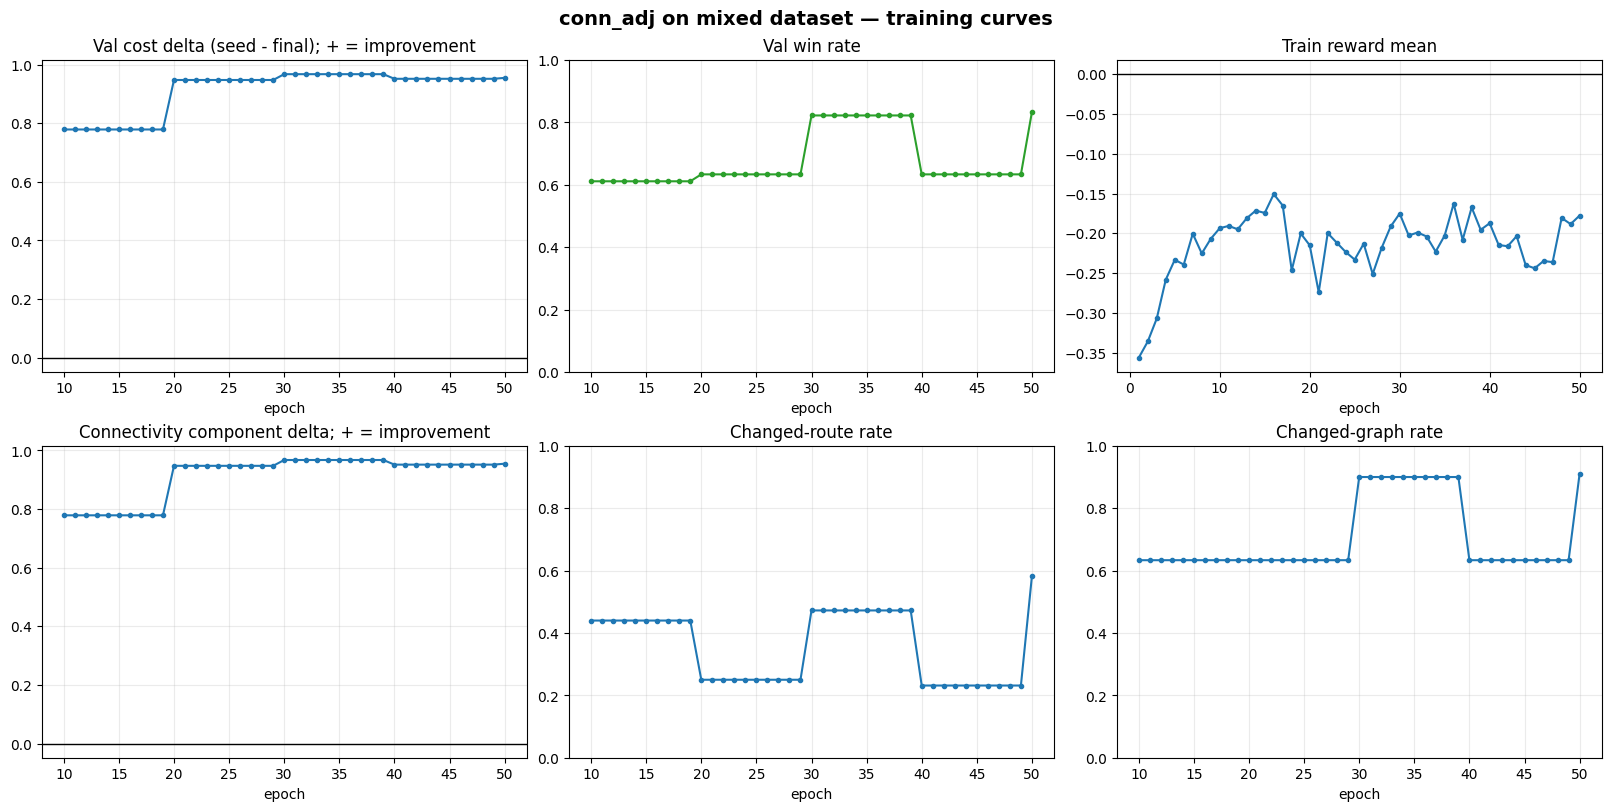

In [7]:
h = history_df


def _safe(ax, col, **kw):
    if col not in h.columns:
        return
    y = pd.to_numeric(h[col], errors="coerce")
    if y.notna().any():
        ax.plot(h["epoch"], y, marker="o", ms=3, **kw)


fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
_safe(axes[0, 0], "val_delta"); axes[0, 0].axhline(0, color="k", lw=1)
axes[0, 0].set_title("Val cost delta (seed - final); + = improvement")
_safe(axes[0, 1], "val_win_rate", color="tab:green"); axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title("Val win rate")
_safe(axes[0, 2], "train_reward_mean"); axes[0, 2].axhline(0, color="k", lw=1)
axes[0, 2].set_title("Train reward mean")
_safe(axes[1, 0], "val_component_delta_connectivity")
axes[1, 0].axhline(0, color="k", lw=1)
axes[1, 0].set_title("Connectivity component delta; + = improvement")
_safe(axes[1, 1], "val_changed_route_rate"); axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title("Changed-route rate")
_safe(axes[1, 2], "val_changed_graph_rate"); axes[1, 2].set_ylim(0, 1)
axes[1, 2].set_title("Changed-graph rate")
for ax in axes.flat:
    ax.set_xlabel("epoch"); ax.grid(alpha=0.25)
fig.suptitle("conn_adj on mixed dataset — training curves",
             fontsize=14, fontweight="bold")
plt.show()
plt.close(fig)

## Третья модель: route + connectivity + adj

То же обучение, но objective = **route-time + connectivity** (отключён только
`demand`). Возврат `route`-компонента даёт агенту стимул убирать избыточные/длинные
рёбра (которые conn_adj не трогал). adjustment-настройки идентичны. Веса ->
`improvement_route_conn_adj_mixed.pt`, история -> `route_conn_adj_mixed_training_history.csv`.

In [ ]:
# --- Третья модель: route + connectivity + adj (route-time ВКЛ) ---
ROUTE_DISABLED = ["demand"]          # активны route И connectivity
ROUTE_CFG_NAME = "route_conn_adj_mixed"


def _build_edit_overrides(run_cfg_name):
    """Те же overrides, что и у conn_adj (adjustment/conditioning); отличается
    лишь run_name. Маска компонент задаётся отдельно set_enabled_components."""
    ov = [
        "model=bestsofar_feb2023_trim",
        "model.route_generator.kwargs.serial_halting=True",
        f"++run_name={run_cfg_name}",
        "++experiment.logdir=null",
        f"++adjustment_degree_weight={float(ADJ_WEIGHT)}",
        f"++adjustment_degree_target={float(ADJ_TARGET)}",
        f"++adjustment_degree_objective={ADJ_OBJECTIVE}",
        f"++adjustment_degree_gap={float(ADJ_GAP)}",
        f"++adjustment_degree_mode={ADJ_MODE}",
    ]
    if CONDITION_ON_ADJ:
        ov += [
            f"+model.route_generator.kwargs.n_adjustment_cond_feats={N_ADJ_COND_FEATS}",
            "++adjustment_conditioning=true",
            f"++adjustment_condition_weight={str(ADJ_CONDITION_WEIGHT).lower()}",
            f"++adjustment_condition_current={str(ADJ_CONDITION_CURRENT).lower()}",
            f"++adjustment_target_min={float(ADJ_TARGET_MIN)}",
            f"++adjustment_target_max={float(ADJ_TARGET_MAX)}",
            f"++adjustment_weight_min={float(ADJ_WEIGHT_MIN)}",
            f"++adjustment_weight_max={float(ADJ_WEIGHT_MAX)}",
        ]
    return ov


with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
    cfg_route = compose(config_name="ppo_50nodes.yaml",
                        overrides=_build_edit_overrides(ROUTE_CFG_NAME))
_, run_name_route, _, cost_obj_route, model_route = \
    lrnu.process_standard_experiment_cfg(cfg_route, run_name_prefix="improvement_")
cost_obj_route.ignore_stops_oob = True
cost_obj_route.set_enabled_components(disabled_components=ROUTE_DISABLED or None)
ROUTE_CONN_ADJ_PATH = EDIT_MODEL_WEIGHTS_DIR / f"{run_name_route}.pt"
assert ROUTE_CONN_ADJ_PATH.name != BEST_MODEL_PATH.name, "пересечение с conn_adj!"
print(f"Run name: {run_name_route} | enabled: {list(cost_obj_route.enabled_component_names)}")

route_result = train_lc_improvement_cfg(
    model=model_route, cost_obj=cost_obj_route, graphs=graphs, seed_routes=seed_routes,
    device=device, cfg=cfg_route, output_dir=MODEL_OUTPUTS_DIR, run_name=run_name_route,
    train_fraction=TRAIN_FRACTION, batch_size=BATCH_SIZE,
    min_route_len=MIN_ROUTE_LEN, max_route_len=MAX_ROUTE_LEN, seed=SPLIT_SEED,
    force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
    max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
    max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
    target_n_routes=TARGET_N_ROUTES,
    train_indices=TRAIN_INDICES, val_indices=VAL_INDICES,
    best_model_path=ROUTE_CONN_ADJ_PATH, n_iterations=N_ITERATIONS,
)
route_history_df = pd.DataFrame(route_result["history"])
save_table(route_history_df, "route_conn_adj_mixed_training_history")
print(f"Best model: {ROUTE_CONN_ADJ_PATH}")

Run name: improvement_route_conn_adj_mixed | enabled: ['route', 'connectivity']


feature norm:  75%|███████▌  | 3/4 [00:58<00:19, 19.52s/it]D:\PythonProjects\connectpt\connectpt\routes_generator\models.py:632: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  x_var = xx.var(0).detach()
cfg ppo improvement:   2%|▏         | 1/50 [01:50<1:30:05, 110.32s/it, reward=-0.353, delta=-0.637, ratio=1.003, clip=36.26%]

cfg_ppo_iter=001 reward=-0.3528 train_delta=-0.6367 val_delta=nan ratio=1.003 clip=36.26% actions=ext:330 trim_s:140 trim_e:136 halt:751 avg_steps=1.80 eval=False


cfg ppo improvement:   4%|▍         | 2/50 [03:55<1:35:28, 119.34s/it, reward=-0.323, delta=-0.641, ratio=1.002, clip=0.00%] 

cfg_ppo_iter=002 reward=-0.3228 train_delta=-0.6414 val_delta=nan ratio=1.002 clip=0.00% actions=ext:406 trim_s:145 trim_e:146 halt:702 avg_steps=1.99 eval=False


...

cfg_ppo_iter=018 reward=-0.2127 train_delta=-0.5287 val_delta=0.7657 ratio=1.002 clip=11.20% actions=ext:552 trim_s:124 trim_e:115 halt:521 avg_steps=2.48 eval=False


cfg ppo improvement:  38%|███▊      | 19/50 [39:42<1:04:10, 124.22s/it, reward=-0.219, delta=-0.549, ratio=0.999, clip=10.14%]

cfg_ppo_iter=019 reward=-0.2187 train_delta=-0.5486 val_delta=0.7657 ratio=0.999 clip=10.14% actions=ext:497 trim_s:89 trim_e:115 halt:463 avg_steps=2.51 eval=False


cfg ppo improvement:  40%|████      | 20/50 [45:23<1:34:37, 189.23s/it, reward=-0.242, delta=-0.555, ratio=0.986, clip=16.90%]

cfg_ppo_iter=020 reward=-0.2417 train_delta=-0.5553 val_delta=0.9369 ratio=0.986 clip=16.90% actions=ext:493 trim_s:93 trim_e:100 halt:527 avg_steps=2.30 eval=True


## Сравнение двух моделей на mixed-val

Обе политики прогоняются greedy на одном и том же подмножестве mixed-val,
каждая — в своём «родном» objective (для conn_adj_mixed это connectivity-only;
для train_improvement — demand+route). Результат измеряется под **единым полным**
objective (ATT/RTT/MC абсолютны, не зависят от маски), плюс adjustment vs seed.

- **conn_adj_mixed** — обучен на этом датасете (in-distribution).
- **train_improvement** — старая модель (50 узлов / 10 маршрутов / len 12),
  применяется к новому датасету **zero-shot** (GNN индуктивна).

Это показывает, что даёт обучение conn_adj на новом датасете против
переиспользования существующей improvement-модели.

In [ ]:
EVAL_N_GRAPHS = min(40, len(VAL_INDICES))   # подмножество val для скорости
_eval_idx = VAL_INDICES[:EVAL_N_GRAPHS].tolist()

# Единый full-objective (все 3 компонента) -> сопоставимые абсолютные ATT/RTT/MC.
with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
    _full_cfg = compose(config_name="ppo_50nodes.yaml", overrides=[
        "model=bestsofar_feb2023_trim",
        "model.route_generator.kwargs.serial_halting=True",
        "++run_name=cmp_full", "++experiment.logdir=null"])
_, _, _, FULL_COST, _ = lrnu.process_standard_experiment_cfg(
    _full_cfg, run_name_prefix="cmpfull_", weights_required=False)
FULL_COST.ignore_stops_oob = True


def _sc(v):
    return float(v.detach().reshape(-1)[0].cpu()) if torch.is_tensor(v) else float(v)


def _full_metrics(gidx, routes):
    gb = Batch.from_data_list([graphs[gidx].clone()]).to(device)
    rt = routes.to(device)
    if rt.ndim == 2:
        rt = rt[None]
    st = RouteGenBatchState(gb, FULL_COST, TARGET_N_ROUTES, MIN_ROUTE_LEN, MAX_ROUTE_LEN)
    st.add_new_routes(rt)
    r = FULL_COST(st)
    m = r.get_metrics()
    return (_sc(m.get("ATT", float("nan"))), _sc(m.get("RTT", float("nan"))),
            _sc(m.get("median_connectivity", float("nan"))), _sc(r.cost))


def _build_model(weights_path, disabled, n_cond=0):
    ov = ["model=bestsofar_feb2023_trim",
          "model.route_generator.kwargs.serial_halting=True",
          "++run_name=cmp", "++experiment.logdir=null"]
    if n_cond:
        # conditioned-веса несовместимы с не-conditioned scorer'ами -> строим
        # модель с тем же n_adjustment_cond_feats, иначе load_state_dict падает.
        ov.append(
            f"+model.route_generator.kwargs.n_adjustment_cond_feats={int(n_cond)}")
    with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
        c = compose(config_name="ppo_50nodes.yaml", overrides=ov)
    _, _, _, cobj, m = lrnu.process_standard_experiment_cfg(
        c, run_name_prefix="cmp_", weights_required=False)
    cobj.ignore_stops_oob = True
    cobj.set_enabled_components(disabled_components=disabled or None)
    m.load_state_dict(torch.load(weights_path, map_location=device))
    m.to(device).eval()
    return m, cobj


# (weights, disabled_components, n_adjustment_cond_feats, eval_target, eval_weight).
# conn_adj_mixed conditioned -> оцениваем в фикс. точке EVAL_ADJ_TARGET/WEIGHT.
# train_improvement -- старая не-conditioned модель (n_cond=0, target=None).
MODELS_CMP = {
    "route_conn_adj": (ROUTE_CONN_ADJ_PATH, ROUTE_DISABLED,
                       N_ADJ_COND_FEATS,
                       EVAL_ADJ_TARGET if CONDITION_ON_ADJ else None,
                       EVAL_ADJ_WEIGHT if CONDITION_ON_ADJ else None),
    "conn_adj_mixed": (BEST_MODEL_PATH, DISABLED_COST_COMPONENTS,
                       N_ADJ_COND_FEATS,
                       EVAL_ADJ_TARGET if CONDITION_ON_ADJ else None,
                       EVAL_ADJ_WEIGHT if CONDITION_ON_ADJ else None),
    "train_improvement": (EDIT_MODEL_WEIGHTS_DIR / f"{BASELINE_RUN_NAME}.pt",
                          ["connectivity"], 0, None, None),  # demand+route
}

# seed baseline (одинаков для обеих моделей)
_seed = np.array([_full_metrics(gi, seed_routes[gi]) for gi in _eval_idx])
cmp_rows = [{"model": "seed (init)", "ATT": _seed[:, 0].mean(),
             "RTT": _seed[:, 1].mean(), "MC": _seed[:, 2].mean(),
             "full_cost": _seed[:, 3].mean(), "adj_vs_seed": 0.0,
             "adj>target": 0, "adj>target_rate": 0.0, "win_rate": float("nan")}]

# Per-graph adjustment по каждой модели (выровнено с _eval_idx) -- для подсчёта
# превышений target и для выбора графа с макс. разницей в визуализации.
ADJ_BY_MODEL = {}

for name, (wpath, disabled, n_cond, ev_t, ev_w) in MODELS_CMP.items():
    if not Path(wpath).exists():
        print(f"[skip] {name}: нет весов {wpath}")
        continue
    m, cobj = _build_model(wpath, disabled, n_cond)
    cw = cobj.get_weights(device)
    att, rtt, mc, fc, adj, won = [], [], [], [], [], 0
    for gi in _eval_idx:
        gb, rb = make_improvement_batch(
            graphs, seed_routes, torch.tensor([gi]), device, training=False,
            target_n_routes=TARGET_N_ROUTES)
        with torch.no_grad():
            out = rollout_lc_improvement(
                m, cobj, gb, rb, MIN_ROUTE_LEN, MAX_ROUTE_LEN, greedy=True,
                cost_weights=cw, max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
                max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
                adjustment_target=ev_t, adjustment_weight=ev_w,
                adjustment_use_current=USE_CURRENT_ADJ_EVAL)
        imp = get_batch_tensor_from_routes(out[0].routes, device,
                                           max_route_len=rb.shape[-1])
        a, r, mcv, fcv = _full_metrics(gi, imp[0])
        att.append(a); rtt.append(r); mc.append(mcv); fc.append(fcv)
        # win = улучшил ли full_cost относительно seed
        won += (fcv < _seed[_eval_idx.index(gi), 3] - 1e-9)
        sf = rb.to(device)
        nr = min(imp.shape[1], sf.shape[1]); w = min(imp.shape[-1], sf.shape[-1])
        adj.append(get_adjustment_degrees(
            imp[:, :nr, :w], sf[:, :nr, :w], cobj.symmetric_routes,
            gap=ADJ_GAP, mode=ADJ_MODE).mean().item())
    adj_arr = np.array(adj)
    ADJ_BY_MODEL[name] = adj_arr
    over = int((adj_arr > ADJ_TARGET).sum())   # на скольких графах adj > target
    cmp_rows.append({"model": name, "ATT": np.mean(att), "RTT": np.mean(rtt),
                     "MC": np.mean(mc), "full_cost": np.mean(fc),
                     "adj_vs_seed": float(adj_arr.mean()),
                     "adj>target": over,
                     "adj>target_rate": over / len(adj_arr),
                     "win_rate": won / len(_eval_idx)})
    print(f"{name:18s} done  | adj>target ({ADJ_TARGET}): {over}/{len(adj_arr)} graphs")

cmp_df = pd.DataFrame(cmp_rows)[
    ["model", "ATT", "RTT", "MC", "full_cost", "adj_vs_seed",
     "adj>target", "adj>target_rate", "win_rate"]].round(3)
print(f"\nVal subset: {len(_eval_idx)} graphs | adjustment target = {ADJ_TARGET}"
      + (f" (conditioned eval @ target={EVAL_ADJ_TARGET}"
        + (f", W={EVAL_ADJ_WEIGHT:.2f}" if EVAL_ADJ_WEIGHT is not None else " | W фикс вне фичей") + ")"
         if CONDITION_ON_ADJ else ""))
display(cmp_df)
save_table(cmp_df, f"{EXPERIMENT_NAME}_vs_train_improvement")
print(f"Saved -> artifacts/results/{EXPERIMENT_NAME}_vs_train_improvement.csv")

conn_adj_mixed     done  | adj>target (0.15): 16/40 graphs
train_improvement  done  | adj>target (0.15): 27/40 graphs

Val subset: 40 graphs | adjustment target = 0.15 (conditioned eval @ target=0.15 | W фикс вне фичей)


,model,ATT,RTT,MC,full_cost,adj_vs_seed,adj>target,adj>target_rate,win_rate
0,seed (init),30.567,1334.406,26.537,2.030,0.000,0,0.000,NaN
1,conn_adj_mixed,31.414,1370.453,26.955,0.899,0.140,16,0.400,0.750
2,train_improvement,33.427,1271.164,28.141,0.875,0.199,27,0.675,0.875


[results] table (3 rows) -> D:\PythonProjects\connectpt\artifacts\results\conn_adj_mixed_vs_train_improvement.csv
Saved -> artifacts/results/conn_adj_mixed_vs_train_improvement.csv


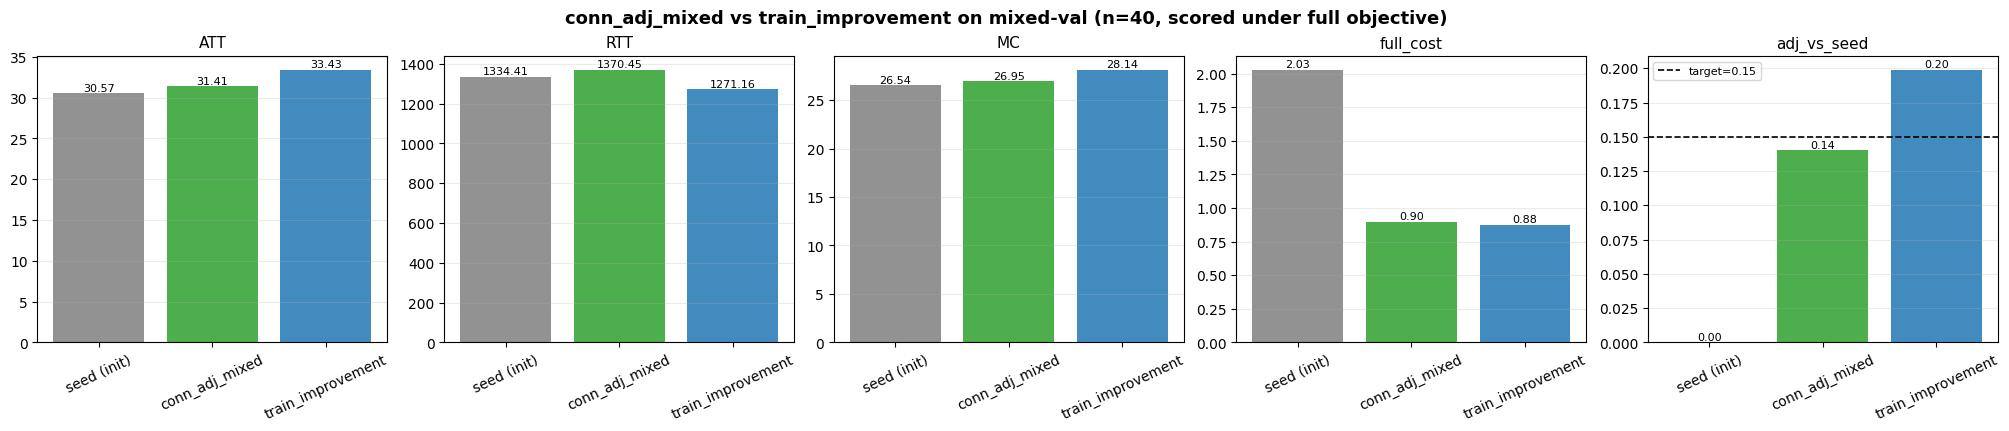

In [ ]:
_metrics = ["ATT", "RTT", "MC", "full_cost", "adj_vs_seed"]
_order = list(cmp_df["model"])
_colors = {"seed (init)": "tab:gray",
           "route_conn_adj": "tab:orange",
           "conn_adj_mixed": "tab:green",
           "train_improvement": "tab:blue"}
_row = {r["model"]: r for _, r in cmp_df.iterrows()}

fig, axes = plt.subplots(1, len(_metrics), figsize=(20, 4.2),
                         constrained_layout=True)
for ax, metric in zip(axes, _metrics):
    vals = [_row[v][metric] for v in _order]
    bars = ax.bar(_order, vals, color=[_colors.get(v, "tab:blue") for v in _order],
                  alpha=0.85)
    if metric == "adj_vs_seed":
        ax.axhline(ADJ_TARGET, color="black", linestyle="--", linewidth=1.2,
                   label=f"target={ADJ_TARGET}")
        ax.legend(fontsize=8)
    ax.set_title(metric, fontsize=11)
    ax.tick_params(axis="x", rotation=25)
    ax.grid(alpha=0.25, axis="y")
    for b, val in zip(bars, vals):
        if np.isfinite(val):
            ax.annotate(f"{val:.2f}", (b.get_x() + b.get_width() / 2, val),
                        ha="center", va="bottom", fontsize=8)
fig.suptitle(
    f"conn_adj_mixed vs train_improvement on mixed-val (n={EVAL_N_GRAPHS}, "
    f"scored under full objective)", fontsize=13, fontweight="bold")
plt.show()
plt.close(fig)

## Прогон по типам графов (nx_heuristic / lc / rpc)

Каждая из трёх моделей прогоняется greedy на val-подмножестве **по каждому
типу графа** отдельно (раскладка датасета: первые `N_PER_TYPE` — heuristic, затем lc,
затем rpc). Оценка под единым полным objective. CSV -> `conn_adj_mixed_by_graph_type.csv`.

In [ ]:
# --- Прогон по 3 типам графов (nx_heuristic / lc / rpc) ---
def _graph_type(i):
    return GEN_TYPES[min(i // N_PER_TYPE, len(GEN_TYPES) - 1)]

PER_TYPE_N = 12   # графов val на каждый тип
type_to_idxs = {t: [] for t in GEN_TYPES}
for gi in VAL_INDICES.tolist():
    t = _graph_type(gi)
    if len(type_to_idxs[t]) < PER_TYPE_N:
        type_to_idxs[t].append(gi)
print("val графов по типам:", {t: len(v) for t, v in type_to_idxs.items()})

bytype_rows = []
for name, (wpath, disabled, n_cond, ev_t, ev_w) in MODELS_CMP.items():
    if not Path(wpath).exists():
        print(f"[skip] {name}: нет весов")
        continue
    m, cobj = _build_model(wpath, disabled, n_cond)
    cw = cobj.get_weights(device)
    for t, idxs in type_to_idxs.items():
        if not idxs:
            continue
        fcs, adjs, wins = [], [], 0
        for gi in idxs:
            gb, rb = make_improvement_batch(
                graphs, seed_routes, torch.tensor([gi]), device,
                training=False, target_n_routes=TARGET_N_ROUTES)
            with torch.no_grad():
                out = rollout_lc_improvement(
                    m, cobj, gb, rb, MIN_ROUTE_LEN, MAX_ROUTE_LEN, greedy=True,
                    cost_weights=cw, max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
                    max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
                    adjustment_target=ev_t, adjustment_weight=ev_w,
                    adjustment_use_current=USE_CURRENT_ADJ_EVAL)
            imp = get_batch_tensor_from_routes(out[0].routes, device,
                                               max_route_len=rb.shape[-1])
            seed_fc = _full_metrics(gi, seed_routes[gi])[3]
            fc = _full_metrics(gi, imp[0])[3]
            fcs.append(fc); wins += int(fc < seed_fc - 1e-9)
            sf = rb.to(device)
            nr = min(imp.shape[1], sf.shape[1]); w = min(imp.shape[-1], sf.shape[-1])
            adjs.append(get_adjustment_degrees(
                imp[:, :nr, :w], sf[:, :nr, :w], cobj.symmetric_routes,
                gap=ADJ_GAP, mode=ADJ_MODE).mean().item())
        bytype_rows.append({"model": name, "graph_type": t, "n": len(idxs),
                            "full_cost": float(np.mean(fcs)),
                            "adj_vs_seed": float(np.mean(adjs)),
                            "win_rate": wins / len(idxs)})
    print(f"{name} done")

bytype_df = pd.DataFrame(bytype_rows).round(3)
print("\nfull_cost (model x graph_type):")
display(bytype_df.pivot(index="model", columns="graph_type", values="full_cost"))
display(bytype_df)
save_table(bytype_df, f"{EXPERIMENT_NAME}_by_graph_type")

_types = list(type_to_idxs.keys())
_models = bytype_df["model"].unique().tolist()
fig, ax = plt.subplots(figsize=(11, 4.5))
xs = np.arange(len(_types)); width = 0.8 / max(len(_models), 1)
for k, mname in enumerate(_models):
    sub = bytype_df[bytype_df["model"] == mname].set_index("graph_type")
    vals = [sub.loc[t, "full_cost"] if t in sub.index else np.nan for t in _types]
    ax.bar(xs + k * width, vals, width, label=mname)
ax.set_xticks(xs + width * (len(_models) - 1) / 2); ax.set_xticklabels(_types)
ax.set_ylabel("full_cost (ниже=лучше)"); ax.legend(fontsize=8)
ax.set_title("full_cost по типам графов x модели", fontweight="bold")
ax.grid(alpha=0.25, axis="y")
plt.tight_layout(); plt.show(); plt.close(fig)

## Управляемость: один агент под разные `target` (target-sweep)

Главная проверка **новой логики conditioning**. Та же conditioned-модель
`conn_adj_mixed` прогоняется на одном val-подмножестве при разных **запрошенных**
`target ∈ {0.10…0.40}` (вес `W` фиксирован = `EVAL_ADJ_WEIGHT`). Агент видит
запрошенный порог в global-фичах и должен адаптировать «бюджет переписывания»:

- **достигнутый `adj`** растёт с запрошенным `target` (точки тянутся вдоль `y=x`);
- **`full_cost`** улучшается при больших `target` (разрешено больше менять).

Если линия плоская — conditioning не выучился; если близка к `y=x` и `full_cost`
монотонно падает — управляемый бюджет работает.

target=0.10 -> achieved_adj=0.141, adj<=target 40%, full_cost=0.917
target=0.15 -> achieved_adj=0.140, adj<=target 60%, full_cost=0.899
target=0.20 -> achieved_adj=0.140, adj<=target 70%, full_cost=0.916
target=0.25 -> achieved_adj=0.136, adj<=target 85%, full_cost=0.916
target=0.30 -> achieved_adj=0.135, adj<=target 92%, full_cost=0.916
target=0.40 -> achieved_adj=0.135, adj<=target 98%, full_cost=0.916


,req_target,achieved_adj,adj<=target_rate,full_cost
0,0.10,0.141,0.400,0.917
1,0.15,0.140,0.600,0.899
2,0.20,0.140,0.700,0.916
3,0.25,0.136,0.850,0.916
4,0.30,0.135,0.925,0.916
5,0.40,0.135,0.975,0.916


[results] table (6 rows) -> D:\PythonProjects\connectpt\artifacts\results\conn_adj_mixed_target_sweep.csv


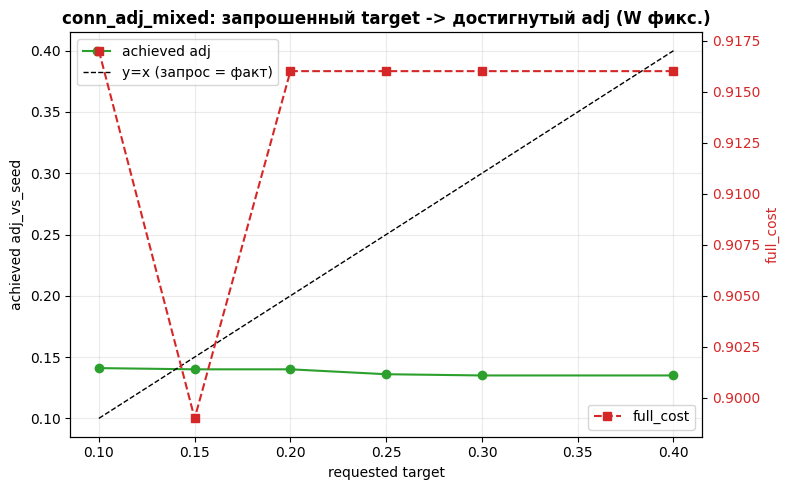

In [ ]:
# --- Контролируемость: ОДИН conditioned-агент под РАЗНЫЕ запрошенные target ---
# Прогоняем conn_adj_mixed на одном и том же val-подмножестве, меняя только
# запрошенный target (W фикс. = EVAL_ADJ_WEIGHT). Если conditioning реально
# работает: достигнутый adj должен РАСТИ с запрошенным target (агенту разрешают
# больше переписывать), а full_cost при этом — улучшаться. Это ключевая
# демонстрация «управляемого бюджета переписывания».
if not CONDITION_ON_ADJ:
    print("CONDITION_ON_ADJ=False -> target-sweep пропущен (модель знает один режим)")
elif not Path(BEST_MODEL_PATH).exists():
    print(f"[skip] нет весов {BEST_MODEL_PATH}")
else:
    SWEEP_TARGETS = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40]
    _sm, _scobj = _build_model(BEST_MODEL_PATH, DISABLED_COST_COMPONENTS, N_ADJ_COND_FEATS)
    _scw = _scobj.get_weights(device)
    sweep_rows = []
    for t in SWEEP_TARGETS:
        adj, fc = [], []
        for gi in _eval_idx:
            gb, rb = make_improvement_batch(
                graphs, seed_routes, torch.tensor([gi]), device,
                training=False, target_n_routes=TARGET_N_ROUTES)
            with torch.no_grad():
                out = rollout_lc_improvement(
                    _sm, _scobj, gb, rb, MIN_ROUTE_LEN, MAX_ROUTE_LEN, greedy=True,
                    cost_weights=_scw, max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
                    max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
                    adjustment_target=t, adjustment_weight=EVAL_ADJ_WEIGHT,
                    adjustment_use_current=USE_CURRENT_ADJ_EVAL)
            imp = get_batch_tensor_from_routes(out[0].routes, device,
                                               max_route_len=rb.shape[-1])
            sf = rb.to(device)
            nr = min(imp.shape[1], sf.shape[1]); w = min(imp.shape[-1], sf.shape[-1])
            adj.append(get_adjustment_degrees(
                imp[:, :nr, :w], sf[:, :nr, :w], _scobj.symmetric_routes,
                gap=ADJ_GAP, mode=ADJ_MODE).mean().item())
            fc.append(_full_metrics(gi, imp[0])[3])
        adj = np.array(adj); fc = np.array(fc)
        sweep_rows.append({"req_target": t, "achieved_adj": float(adj.mean()),
                           "adj<=target_rate": float((adj <= t).mean()),
                           "full_cost": float(fc.mean())})
        print(f"target={t:.2f} -> achieved_adj={adj.mean():.3f}, "
              f"adj<=target {(adj <= t).mean() * 100:.0f}%, "
              f"full_cost={fc.mean():.3f}")
    sweep_df = pd.DataFrame(sweep_rows).round(3)
    display(sweep_df)
    save_table(sweep_df, f"{EXPERIMENT_NAME}_target_sweep")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(sweep_df["req_target"], sweep_df["achieved_adj"], "o-",
            color="tab:green", label="achieved adj")
    _lo, _hi = min(SWEEP_TARGETS), max(SWEEP_TARGETS)
    ax.plot([_lo, _hi], [_lo, _hi], "k--", lw=1, label="y=x (запрос = факт)")
    ax.set_xlabel("requested target"); ax.set_ylabel("achieved adj_vs_seed")
    ax.grid(alpha=0.25)
    ax2 = ax.twinx()
    ax2.plot(sweep_df["req_target"], sweep_df["full_cost"], "s--",
             color="tab:red", label="full_cost")
    ax2.set_ylabel("full_cost", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")
    ax.set_title("conn_adj_mixed: запрошенный target -> достигнутый adj "
                 "(W фикс.)", fontsize=12, fontweight="bold")
    ax.legend(loc="upper left"); ax2.legend(loc="lower right")
    plt.tight_layout(); plt.show(); plt.close(fig)

## Управляемость через вес `W` (основной рычаг для `cap`)

Для `cap`-штрафа **W — главный рычаг**, а не `target`: математически градиент
штрафа `= W` при `adj > target`, так что оптимальный `adj` зависит от `W`
(`target` лишь задаёт порог включения). Фиксируем `target=EVAL_ADJ_TARGET`,
свипаем `W ∈ {2…50}`:

- **achieved `adj` падает** с ростом `W` (сильнее штраф → меньше переписывания);
- **`full_cost` растёт** (агент жертвует connectivity ради удержания adj).

Плоская линия = W-фича не выучилась (так было в 1-м прогоне на слабом W=[0.5,8]).

In [ ]:
# --- Контролируемость через W (ОСНОВНОЙ рычаг для cap) ---
# При cap target лишь включает штраф (градиент = W при adj>target). Объём
# переписывания регулирует именно W: фиксируем target=EVAL_ADJ_TARGET, меняем W.
# Если conditioning выучился -> achieved adj ПАДАЕТ с ростом W (сильнее штраф ->
# меньше переписывания), full_cost при этом растёт. Плоская линия = W-фича не
# выучилась (как было в 1-м прогоне на W=[0.5,8]).
if not (CONDITION_ON_ADJ and ADJ_CONDITION_WEIGHT):
    print("W не кондишенится (ADJ_CONDITION_WEIGHT=False) -> W-sweep пропущен")
elif not Path(BEST_MODEL_PATH).exists():
    print(f"[skip] нет весов {BEST_MODEL_PATH}")
else:
    SWEEP_WEIGHTS = [1.0, 3.0, 6.0, 10.0, 15.0]
    _wm, _wcobj = _build_model(BEST_MODEL_PATH, DISABLED_COST_COMPONENTS, N_ADJ_COND_FEATS)
    _wcw = _wcobj.get_weights(device)
    wsweep_rows = []
    for Wt in SWEEP_WEIGHTS:
        adj, fc = [], []
        for gi in _eval_idx:
            gb, rb = make_improvement_batch(
                graphs, seed_routes, torch.tensor([gi]), device,
                training=False, target_n_routes=TARGET_N_ROUTES)
            with torch.no_grad():
                out = rollout_lc_improvement(
                    _wm, _wcobj, gb, rb, MIN_ROUTE_LEN, MAX_ROUTE_LEN, greedy=True,
                    cost_weights=_wcw, max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
                    max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
                    adjustment_target=EVAL_ADJ_TARGET, adjustment_weight=Wt,
                    adjustment_use_current=USE_CURRENT_ADJ_EVAL)
            imp = get_batch_tensor_from_routes(out[0].routes, device,
                                               max_route_len=rb.shape[-1])
            sf = rb.to(device)
            nr = min(imp.shape[1], sf.shape[1]); w = min(imp.shape[-1], sf.shape[-1])
            adj.append(get_adjustment_degrees(
                imp[:, :nr, :w], sf[:, :nr, :w], _wcobj.symmetric_routes,
                gap=ADJ_GAP, mode=ADJ_MODE).mean().item())
            fc.append(_full_metrics(gi, imp[0])[3])
        adj = np.array(adj); fc = np.array(fc)
        wsweep_rows.append({"req_W": Wt, "achieved_adj": float(adj.mean()),
                            "adj<=target_rate": float((adj <= EVAL_ADJ_TARGET).mean()),
                            "full_cost": float(fc.mean())})
        print(f"W={Wt:5.1f} -> achieved_adj={adj.mean():.3f}, "
              f"adj<={EVAL_ADJ_TARGET} {(adj <= EVAL_ADJ_TARGET).mean() * 100:.0f}%, "
              f"full_cost={fc.mean():.3f}")
    wsweep_df = pd.DataFrame(wsweep_rows).round(3)
    display(wsweep_df)
    save_table(wsweep_df, f"{EXPERIMENT_NAME}_W_sweep")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(wsweep_df["req_W"], wsweep_df["achieved_adj"], "o-",
            color="tab:green", label="achieved adj")
    ax.axhline(EVAL_ADJ_TARGET, color="black", linestyle="--", lw=1,
               label=f"target={EVAL_ADJ_TARGET}")
    ax.set_xscale("log")
    ax.set_xlabel("requested W (log)"); ax.set_ylabel("achieved adj_vs_seed")
    ax.grid(alpha=0.25, which="both")
    ax2 = ax.twinx()
    ax2.plot(wsweep_df["req_W"], wsweep_df["full_cost"], "s--",
             color="tab:red", label="full_cost")
    ax2.set_ylabel("full_cost", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")
    ax.set_title("conn_adj_mixed: вес W -> достигнутый adj (target фикс.)",
                 fontsize=12, fontweight="bold")
    ax.legend(loc="upper right"); ax2.legend(loc="lower left")
    plt.tight_layout(); plt.show(); plt.close(fig)

W не кондишенится (ADJ_CONDITION_WEIGHT=False) -> W-sweep пропущен


## Визуализация маршрутов (diff vs seed + plain)

На одном val-графе для **обеих моделей** + seed:
- **верхний ряд** — diff относительно seed (`plot_route_diff`): пунктир = убранные
  рёбра, бледное = сохранённые, жирное = добавленные;
- **нижний ряд** — просто маршруты без diff (`plot_plain_route_set`); дугами
  показаны дублирующиеся/перекрывающиеся участки.

Граф с макс. разницей adj: #12  |  conn_adj_mixed=0.069, train_improvement=0.297, |Δ|=0.228


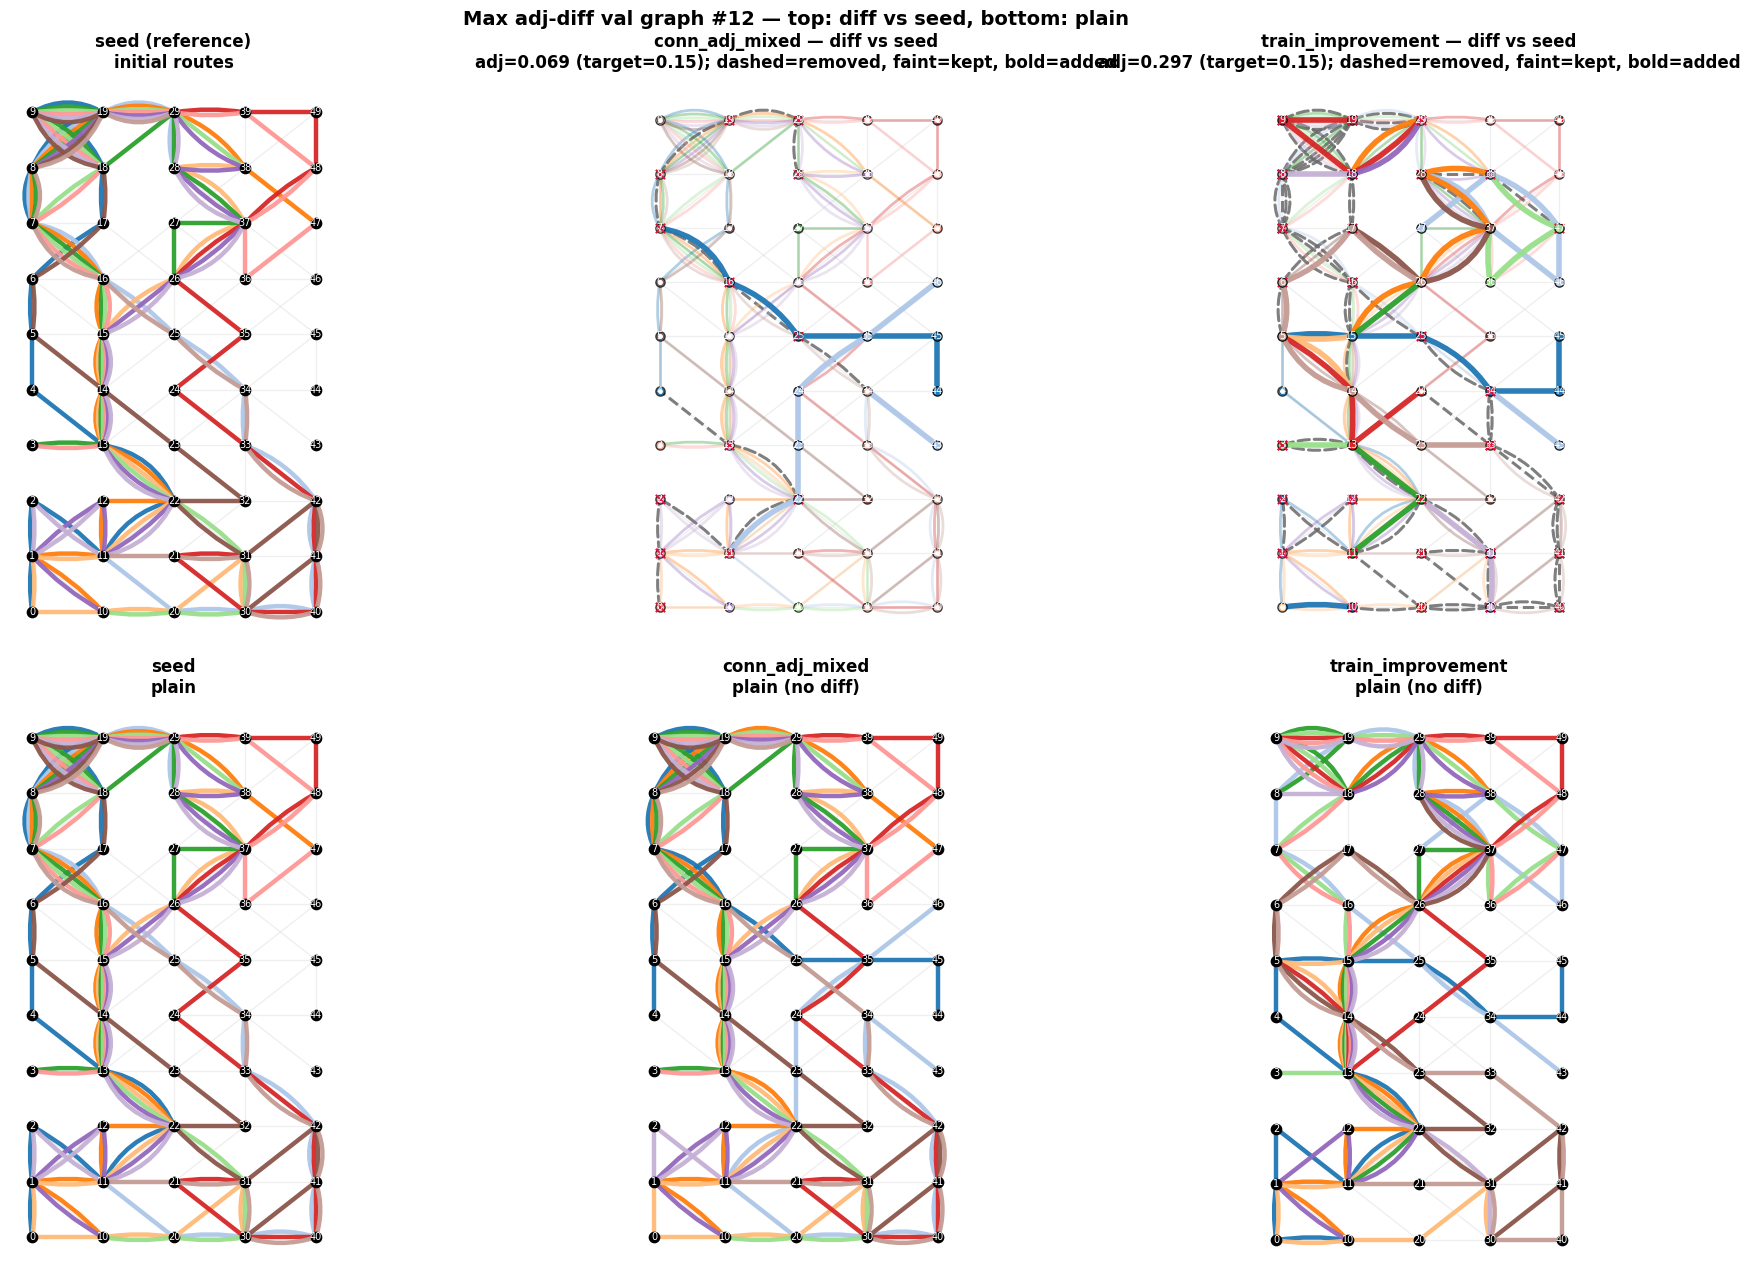

In [ ]:
# Граф с НАИБОЛЬШЕЙ разницей adjustment между двумя моделями.
if len(ADJ_BY_MODEL) >= 2:
    _ma, _mb = list(ADJ_BY_MODEL.keys())[:2]
    _diff = np.abs(ADJ_BY_MODEL[_ma] - ADJ_BY_MODEL[_mb])
    _k = int(np.argmax(_diff))
    FOCUS_GRAPH_IDX = int(_eval_idx[_k])
    print(f"Граф с макс. разницей adj: #{FOCUS_GRAPH_IDX}  |  "
          f"{_ma}={ADJ_BY_MODEL[_ma][_k]:.3f}, "
          f"{_mb}={ADJ_BY_MODEL[_mb][_k]:.3f}, |Δ|={_diff[_k]:.3f}")
else:
    FOCUS_GRAPH_IDX = int(VAL_INDICES[0])
    print(f"Только одна модель -> беру val graph #{FOCUS_GRAPH_IDX}")

focus_graph = graphs[FOCUS_GRAPH_IDX]
_seed_focus = seed_routes[FOCUS_GRAPH_IDX]

VIZ_ROUTES = {"seed": _seed_focus}
for _name, (_wpath, _disabled, _ncond, _evt, _evw) in MODELS_CMP.items():
    if not Path(_wpath).exists():
        print(f"[skip viz] {_name}: нет весов {_wpath}")
        continue
    _m, _cobj = _build_model(_wpath, _disabled, _ncond)
    _cw = _cobj.get_weights(device)
    _gb, _rb = make_improvement_batch(
        graphs, seed_routes, torch.tensor([FOCUS_GRAPH_IDX]), device,
        training=False, target_n_routes=TARGET_N_ROUTES)
    with torch.no_grad():
        _out = rollout_lc_improvement(
            _m, _cobj, _gb, _rb, MIN_ROUTE_LEN, MAX_ROUTE_LEN, greedy=True,
            cost_weights=_cw, max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
            max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
            adjustment_target=_evt, adjustment_weight=_evw,
            adjustment_use_current=USE_CURRENT_ADJ_EVAL)
    VIZ_ROUTES[_name] = get_batch_tensor_from_routes(
        _out[0].routes, device, max_route_len=_rb.shape[-1])[0].cpu()

_model_names = [n for n in MODELS_CMP if n in VIZ_ROUTES]
_ncols = 1 + len(_model_names)   # seed + модели
fig, axes = plt.subplots(2, _ncols, figsize=(7.0 * _ncols, 13),
                         squeeze=False)


def _adj_label(name):
    """adjustment маршрутов модели на этом графе (для подписи)."""
    sf = _seed_focus
    rt = VIZ_ROUTES[name]
    nr = min(rt.shape[0], sf.shape[0]); w = min(rt.shape[1], sf.shape[1])
    return get_adjustment_degrees(
        rt[None, :nr, :w], sf[None, :nr, :w], True,
        gap=ADJ_GAP, mode=ADJ_MODE).mean().item()


# --- Верхний ряд: diff vs seed (пунктир=убрано, бледное=сохранено, жирное=добавлено) ---
_plots.plot_plain_route_set(
    axes[0, 0], VIZ_ROUTES["seed"], focus_graph,
    title="seed (reference)", subtitle="initial routes",
    palette="tab20", with_overlap_curves=True)
for j, name in enumerate(_model_names, start=1):
    _plots.plot_route_diff(
        axes[0, j], VIZ_ROUTES[name], VIZ_ROUTES["seed"], focus_graph,
        title=f"{name} — diff vs seed",
        subtitle=f"adj={_adj_label(name):.3f} (target={ADJ_TARGET}); "
                 f"dashed=removed, faint=kept, bold=added",
        palette="tab20", with_overlap_curves=True)

# --- Нижний ряд: просто маршруты (без diff), дугами — перекрытия ---
_plots.plot_plain_route_set(
    axes[1, 0], VIZ_ROUTES["seed"], focus_graph,
    title="seed", subtitle="plain", palette="tab20", with_overlap_curves=True)
for j, name in enumerate(_model_names, start=1):
    _plots.plot_plain_route_set(
        axes[1, j], VIZ_ROUTES[name], focus_graph,
        title=name, subtitle="plain (no diff)",
        palette="tab20", with_overlap_curves=True)

fig.suptitle(
    f"Max adj-diff val graph #{FOCUS_GRAPH_IDX} — top: diff vs seed, bottom: plain",
    fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
plt.close(fig)